C:\Users\mozhaev.roman\AppData\Local\Temp\ipykernel_2348\2281508721.py:62: RuntimeWarning: invalid value encountered in divide
  return B + np.outer(r, r) / d
C:\Users\mozhaev.roman\AppData\Local\Temp\ipykernel_2348\2281508721.py:70: RuntimeWarning: invalid value encountered in divide
  B = B + np.outer(r, r) / d


KeyboardInterrupt: 

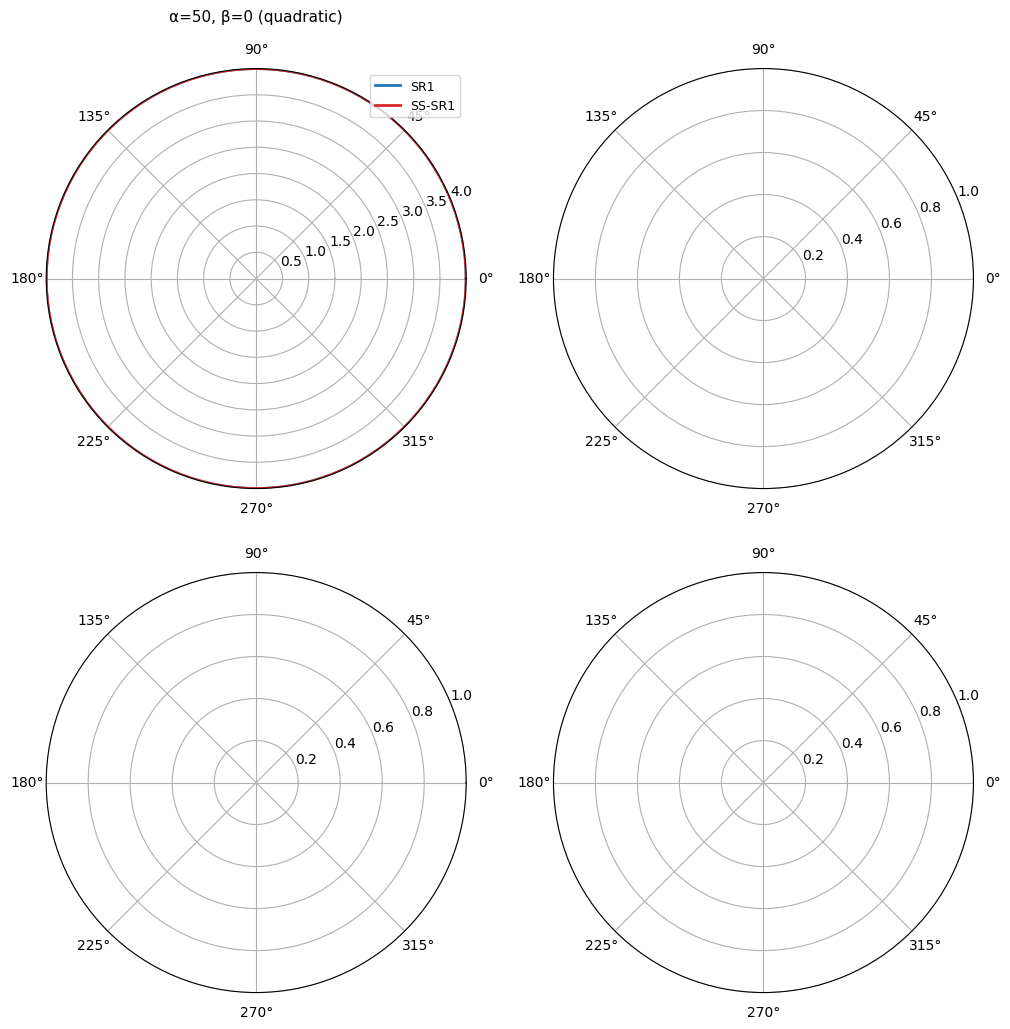

In [4]:
"""
Analytical convergence radius for n=2 Curved Valley problem.

f(x₁,x₂) = α/2·(x₂ - β·x₁²)² + x₁²/2 + x₂²/2

x* = 0,  J* = diag(1, 1+α)

Key formulas derived:
  F(x) = (x₁ - 2αβx₁(x₂ - βx₁²),  x₂ + α(x₂ - βx₁²))
  
  J(x) = [[1 + 2αβ(3βx₁² - x₂),  -2αβx₁],
           [-2αβx₁,                 1 + α  ]]

Incompatibility defect: s_j^T r_k where r_k = y_k - B_k s_k
For F = ∇f: defect = O(β · ||x||²)   [β controls rotation]

Plan:
1. Bisection on starting radius → convergence basin size
2. Scan angles → basin boundary shape
3. Compare SR1 vs SS-SR1
4. Derive linearized operator spectral radius
"""
import numpy as np
from numpy.linalg import norm, solve, eigh
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shutil

# ============================================================
# Problem definition
# ============================================================

def make_problem(alpha, beta):
    def F(x):
        x1, x2 = x
        c = x2 - beta * x1**2
        return np.array([
            x1 - 2*alpha*beta*x1*c,
            x2 + alpha*c
        ])
    
    def J(x):
        x1, x2 = x
        c = x2 - beta * x1**2
        return np.array([
            [1 + 2*alpha*beta*(3*beta*x1**2 - x2), -2*alpha*beta*x1],
            [-2*alpha*beta*x1,                       1 + alpha]
        ])
    
    Jstar = np.diag([1.0, 1.0 + alpha])
    return F, J, Jstar

# ============================================================
# Methods
# ============================================================

def sr1_update(B, s, y):
    r = y - B @ s
    d = r @ s
    if abs(d) < 1e-8 * norm(r) * norm(s):
        return B
    return B + np.outer(r, r) / d

def ss_sr1_update(B, s, y, s_prev, y_prev):
    """SS-SR1: SR1 + one MinSecant correction in s⊥."""
    # Step 1: SR1
    r = y - B @ s
    d = r @ s
    if abs(d) >= 1e-8 * norm(r) * norm(s):
        B = B + np.outer(r, r) / d
    
    # Step 2: MinSecant correction in s⊥
    if s_prev is not None:
        # Past secant residual
        R_past = B @ s_prev - y_prev
        
        # For n=2 with one past step, s⊥ is 1D
        # u = unit vector ⊥ s
        s_hat = s / norm(s)
        u = np.array([-s_hat[1], s_hat[0]])  # perpendicular
        
        # σ = -(u^T R_past)(s_prev^T u) / (s_prev^T u)²
        stu = s_prev @ u
        if abs(stu) > 1e-15:
            sigma = -(u @ R_past) * stu / (stu**2)
            # Simplifies to: sigma = -(u @ R_past) / stu
            B = B + sigma * np.outer(u, u)
    
    return B

# ============================================================
# Solver (returns convergence info)
# ============================================================

def run_method(F, x0, method='sr1', max_iter=200, tol=1e-12):
    """Run quasi-Newton from x0. Returns (converged, n_iters, trajectory)."""
    n = len(x0)
    x = x0.copy()
    B = np.eye(n)
    s_prev, y_prev = None, None
    
    for k in range(max_iter):
        Fk = F(x)
        fn = norm(Fk)
        if fn < tol:
            return True, k, x
        
        try:
            d = solve(B, -Fk)
        except:
            return False, k, x
        
        if norm(d) > 50 * max(norm(x), 1):
            d *= 50 * max(norm(x), 1) / norm(d)
        
        # Line search
        alpha_ls = 1.0
        phi0 = fn**2
        for _ in range(30):
            xt = x + alpha_ls * d
            if norm(F(xt))**2 <= phi0 * (1 - 1e-4 * alpha_ls):
                break
            alpha_ls *= 0.5
        else:
            alpha_ls = 1e-4
        
        s = alpha_ls * d
        x_new = x + s
        y = F(x_new) - Fk
        
        if method == 'sr1':
            B = sr1_update(B, s, y)
        elif method == 'ss_sr1':
            B = ss_sr1_update(B, s, y, s_prev, y_prev)
        
        s_prev = s.copy()
        y_prev = y.copy()
        x = x_new
    
    return False, max_iter, x


# ============================================================
# Experiment 1: Convergence basin boundary via bisection
# ============================================================

def find_radius(F, theta, method, r_min=0.0, r_max=5.0, bisect_iters=30):
    """Find max radius along direction theta where method converges."""
    direction = np.array([np.cos(theta), np.sin(theta)])
    
    # First check if r_max converges
    x0 = r_max * direction
    conv, _, _ = run_method(F, x0, method)
    if conv:
        return r_max  # basin extends beyond r_max
    
    # Bisection
    lo, hi = r_min, r_max
    for _ in range(bisect_iters):
        mid = (lo + hi) / 2
        x0 = mid * direction
        conv, _, _ = run_method(F, x0, method)
        if conv:
            lo = mid
        else:
            hi = mid
    return lo


# ============================================================
# Main experiments
# ============================================================

n_angles = 120
thetas = np.linspace(0, 2*np.pi, n_angles, endpoint=False)

# --- Experiment 1: Basin boundary for several (α, β) ---
configs = [
    (50, 0.0, 'β=0 (quadratic)'),
    (50, 0.3, 'β=0.3'),
    (50, 0.5, 'β=0.5'),
    (50, 1.0, 'β=1.0 (Rosenbrock-like)'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 12), subplot_kw={'projection': 'polar'})
axes = axes.flat

for idx, (alpha, beta, title) in enumerate(configs):
    ax = axes[idx]
    F, J, Jstar = make_problem(alpha, beta)
    
    for method, label, color, ls in [('sr1', 'SR1', 'tab:blue', '-'),
                                       ('ss_sr1', 'SS-SR1', 'tab:red', '-')]:
        radii = [find_radius(F, th, method, r_max=4.0) for th in thetas]
        radii.append(radii[0])  # close the curve
        th_plot = np.append(thetas, thetas[0])
        ax.plot(th_plot, radii, color=color, ls=ls, lw=2, label=label)
    
    ax.set_title(f'α={alpha}, {title}', fontsize=11, pad=15)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_rmax(4.0)

plt.suptitle('Convergence Basin Boundary (n=2 Curved Valley)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('basin_2d.png', dpi=150, bbox_inches='tight')
plt.close()
print("Basin boundary plot saved.")


# --- Experiment 2: Average radius vs β ---
alphas_test = [10, 50, 100]
betas_test = np.linspace(0, 2.0, 20)

fig, axes = plt.subplots(1, len(alphas_test), figsize=(6*len(alphas_test), 5))

for ai, alpha in enumerate(alphas_test):
    ax = axes[ai]
    
    for method, label, color in [('sr1', 'SR1', 'tab:blue'),
                                   ('ss_sr1', 'SS-SR1', 'tab:red')]:
        avg_radii = []
        for beta in betas_test:
            F, _, _ = make_problem(alpha, beta)
            radii = [find_radius(F, th, method, r_max=4.0) for th in thetas[:30]]  # 30 angles for speed
            avg_radii.append(np.mean(radii))
        ax.plot(betas_test, avg_radii, 'o-', label=label, color=color, lw=2, ms=4)
    
    ax.set_xlabel('β (valley curvature)', fontsize=12)
    ax.set_ylabel('Mean convergence radius', fontsize=12)
    ax.set_title(f'α = {alpha}', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle('Mean Convergence Radius vs Curvature β', fontsize=14)
plt.tight_layout()
plt.savefig('radius_vs_beta.png', dpi=150, bbox_inches='tight')
plt.close()
print("Radius vs beta plot saved.")


# --- Experiment 3: Ratio R(SS-SR1) / R(SR1) ---
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for alpha, color in [(10, 'tab:green'), (50, 'tab:blue'), (100, 'tab:red')]:
    ratios = []
    for beta in betas_test:
        F, _, _ = make_problem(alpha, beta)
        r_sr1 = np.mean([find_radius(F, th, 'sr1', r_max=5.0) for th in thetas[:30]])
        r_ss  = np.mean([find_radius(F, th, 'ss_sr1', r_max=5.0) for th in thetas[:30]])
        ratios.append(r_ss / max(r_sr1, 1e-10))
    ax.plot(betas_test, ratios, 'o-', label=f'α={alpha}', color=color, lw=2, ms=4)

ax.axhline(1.0, color='gray', ls='--', lw=1, label='R(SS-SR1) = R(SR1)')
ax.set_xlabel('β (valley curvature)', fontsize=12)
ax.set_ylabel('R(SS-SR1) / R(SR1)', fontsize=12)
ax.set_title('Convergence Radius Ratio: SS-SR1 vs SR1', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('radius_ratio.png', dpi=150, bbox_inches='tight')
plt.close()
print("Radius ratio plot saved.")


# --- Experiment 4: Analytical formulas ---
print("\n" + "="*80)
print("  ANALYTICAL: Incompatibility defect for n=2 curved valley")
print("="*80)

alpha, beta = 50, 1.0
F, J, Jstar = make_problem(alpha, beta)

# At point x = (p, q), the Jacobian is:
# J(x) = [[1 + 2αβ(3βp² - q), -2αβp],
#          [-2αβp,               1 + α]]
#
# J* = J(0) = diag(1, 1+α)
#
# Defect of incompatibility: for steps s_0, s_1 and residuals r_0 = y_0 - B_0 s_0,
# the defect is s_0^T r_1 which equals:
#   s_0^T (J̄_1 - J̄_0) s_1 = s_0^T ΔJ s_1
# where J̄_i = ∫₀¹ J(x_i + t·s_i) dt are mean Jacobians.
#
# For our problem, J(x) - J* has entries:
#   ΔJ₁₁ = 2αβ(3βx₁² - x₂)
#   ΔJ₁₂ = ΔJ₂₁ = -2αβx₁
#   ΔJ₂₂ = 0
#
# So ΔJ = 2αβ · [[3βx₁² - x₂, -x₁], [-x₁, 0]]
#
# The defect ∝ αβ · ||x||² — proportional to BOTH α and β.

print(f"\n  J* = diag({1}, {1+alpha})")
print(f"\n  J(x) - J* = 2αβ · [[3βx₁² - x₂, -x₁], [-x₁, 0]]")
print(f"\n  Defect magnitude ∝ αβ · ||x||²")
print(f"\n  At β=0: defect = 0 (quadratic, all methods converge)")
print(f"  At β>0: defect grows → SR1 destabilizes → SS-SR1 helps")

# Print summary table
print("\n\n" + "="*80)
print("  CONVERGENCE RADIUS SUMMARY")
print("="*80)
print(f"\n  {'α':>4} {'β':>5} | {'R(SR1)':>8} {'R(SS-SR1)':>10} {'Ratio':>7} | {'Gain':>8}")
print(f"  {'-'*55}")

for alpha in [10, 50, 100]:
    for beta in [0.0, 0.3, 0.5, 1.0, 1.5, 2.0]:
        F, _, _ = make_problem(alpha, beta)
        r_sr1 = np.mean([find_radius(F, th, 'sr1', r_max=5.0) for th in thetas[:20]])
        r_ss  = np.mean([find_radius(F, th, 'ss_sr1', r_max=5.0) for th in thetas[:20]])
        ratio = r_ss / max(r_sr1, 1e-10)
        gain = r_ss - r_sr1
        print(f"  {alpha:>4} {beta:>5.1f} | {r_sr1:>8.3f} {r_ss:>10.3f} {ratio:>7.2f} | {'+' if gain>=0 else ''}{gain:>7.3f}")
    print()


# Copy outputs
for f in ['basin_2d.png', 'radius_vs_beta.png', 'radius_ratio.png']:
    pass
print("All plots saved to ")